In [1]:
import sys
original_sys_path = sys.path.copy()
sys.path.append('../')
from utils import *


# 1 coherent state, contrast

In [2]:

all_results = []
for i in range(5):
    with open(f'../pickles/mcsolve_2.65_g0.13_a0.003_10level_qbt_state{i}_summed_padd_back.pkl', 'rb') as file:
        result = pickle.load(file)
    all_results.append(result)

results = [all_results[0],all_results[1],all_results[2]]

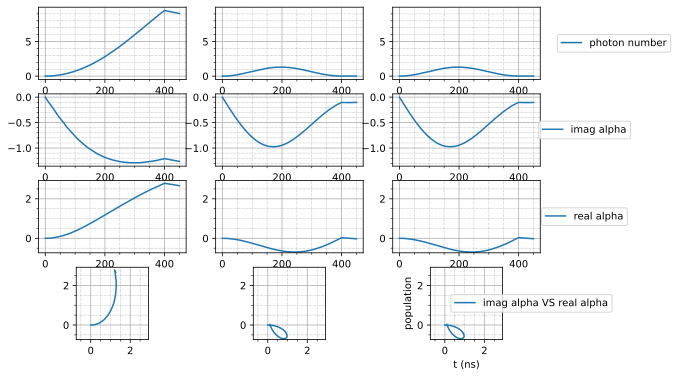

In [7]:
tlist = np.linspace(0, 450, 450)
first_dominant_freq =find_dominant_frequency(results[0].expect[0],tlist)
# first_dominant_freq = w_d


nlevels = 3

fig, axes = plt.subplots(4,nlevels, figsize=(9, 6))

for i in range(nlevels):
    alpha = results[i].expect[-2]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)

    # Coherent state eigenval
    real = alpha.real
    imag = alpha.imag
    axes[1][i].plot(tlist,imag , label=r"imag alpha")
    axes[2][i].plot(tlist, real, label=r"real alpha")
    axes[3][i].plot(-imag, real, label=r"imag alpha VS real alpha")
    
    # Photon number
    axes[0][i].plot(tlist, results[i].expect[-1], label=r"photon number")

axes[0][nlevels-1].legend(loc='center', ncol=1, bbox_to_anchor=(1.5, 0.5))
axes[1][nlevels-1].legend(loc='center', ncol=1, bbox_to_anchor=(1.3, 0.5))
axes[2][nlevels-1].legend(loc='center', ncol=1, bbox_to_anchor=(1.3, 0.5))
axes[3][nlevels-1].legend(loc='center', ncol=1, bbox_to_anchor=(1.4, 0.5))
plt.ylabel("population")
plt.xlabel("t (ns)")
for row in [0,1,2,3]:
    max_x_range,min_x_range,max_y_range,min_y_range = 0,0,0,0
    for col in range(nlevels):
        ymin, ymax = axes[row][col].get_ylim()
        xmin, xmax = axes[row][col].get_xlim()
        if ymax > max_y_range:
            max_y_range = ymax
        if ymin < min_y_range:
            min_y_range = ymin
        if xmax > max_x_range:
            max_x_range = xmax
        if xmin < min_x_range:
            min_x_range = xmin
    for col in range(nlevels):
        axes[row][col].set_ylim(min_y_range, max_y_range)
        axes[row][col].set_xlim(min_x_range,max_x_range)
        # Set the third row y range equal x range
        if row == 3:
            axes[row][col].set_ylim(min(min_x_range,min_y_range), max(max_x_range,max_y_range))
            axes[row][col].set_xlim(min(min_x_range,min_y_range),max(max_x_range,max_y_range))
# plt.yscale('log')
for ax in axes.flat:
    ax.minorticks_on()
    ax.grid(True)
    ax.grid(which='minor', linestyle=':', linewidth='0.5', color='gray')
for col in axes[3]:
    col.set_aspect('equal', 'box')
plt.show()



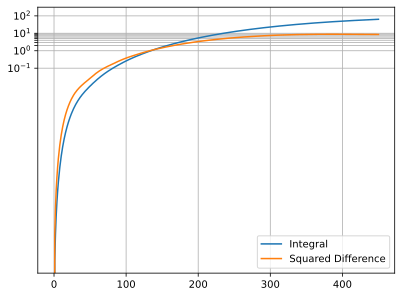

In [8]:
def compute_contrast(results, res_idx1,res_idx2,# Which two results to compute contrast between
                     coeff, # in GHz
                     w_d,tlist,
                     fourier):

    alphas = []
    for i in [res_idx1,res_idx2]:
        alphas.append(results[i].expect[0])

    if fourier == True:
        first_dominant_freq =find_dominant_frequency(alphas[0],tlist)
    else:
        first_dominant_freq = w_d

    alphas[0] = alphas[0]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
    alphas[1] = alphas[1]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)


    # Step-2 do integration
    squared_diff = np.square(abs(alphas[0]-alphas[1]))
    integrals = [0.0]
    for i in range(1,len(tlist)):
        integrals.append(integrals[i-1]+
                         (tlist[i]-tlist[i-1])*coeff*squared_diff[i]
                         )
    # Step-3 Plot
    plt.figure()
    plt.plot(tlist, integrals, label='Integral')
    plt.plot(tlist, squared_diff, label='Squared Difference')
    plt.yscale('log')
    plt.yticks([0.1,1, 2, 3, 4, 5, 6, 7, 8, 9, 10,100])
    plt.legend()
    plt.grid()
    plt.show()
    return integrals

integrals = compute_contrast(results = results, 
                 res_idx1= 0, 
                 res_idx2 = 1,
                coeff = np.sqrt(1e-3),
                w_d = 7.17391479,
                tlist = results[0].times,
                fourier = True)


# additional leakage due to state transfer

In [3]:
system = fluxonium_oscillator_system(
    EJ = 2.65,
    EC = 0.6,
    EL = 0.13,
    Er = 7.17391479,
    g_strength = 0.13,
    qubit_level = 25,
    osc_level = 40,
    kappa =1e-3,
    products_to_keep=[[ql, ol] for ql in [1,10,  2,9,11] for ol in range(20) ],
    computaional_states = '1,2',
    )

interactive_heatmap(results[1], system.product_to_dressed, system.qbt.truncated_dim, system.osc.truncated_dim)


interactive(children=(IntSlider(value=0, continuous_update=False, description='Time Index:', max=449), Output(…

(0.0, 0.02)

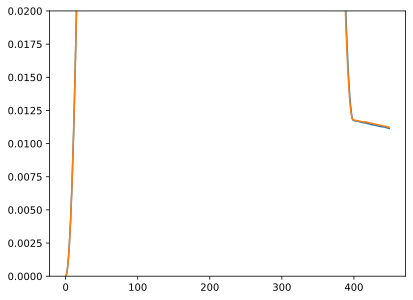

In [13]:
plt.plot(results[1].expect[1])
plt.plot(results[2].expect[1])

plt.ylim(0,0.02)

t loop: 100%|██████████| 450/450 [00:54<00:00,  8.31it/s]


Text(0.5, 0, 't (ns)')

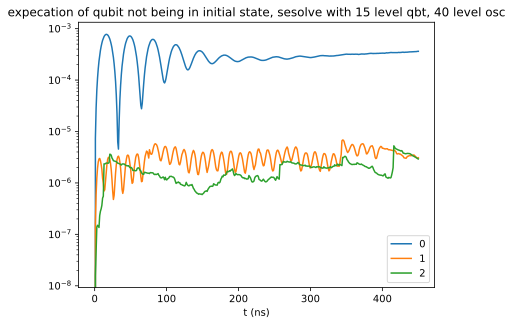

In [12]:
lists = []
for ql in [0,1,2]:
    pop_list = []
    for t_idx in tqdm(range(len(tlist)), desc = "t loop"):
        dm = results[ql].states[t_idx]
        pop_sum = 0
        for q in range(system.qbt.truncated_dim):
            if q != ql:
                for o in range(system.osc.truncated_dim):
                    product_state = (q, o)
                    dressed_state = system.product_to_dressed[product_state]
                    basis_state = qutip.basis(dm.dims[0][0], dressed_state)
                    expectation_value = qutip.expect(basis_state * basis_state.dag(), dm)
                    pop_sum += expectation_value

        pop_list.append(pop_sum)
    # print(pop_list)
    lists.append(pop_list)
with open('../pickles/mcsolve_g0.13_a0.003_leakage_list.pkl', 'wb') as file:
    pickle.dump(lists, file)
with open('../pickles/mcsolve_g0.13_a0.003_leakage_list.pkl', 'rb') as file:
    lists = pickle.load(file)


for ql,pop_list in enumerate(lists): 
    plt.plot(tlist,pop_list,label = f"{ql}")
plt.yscale('log')
plt.legend()
plt.title('expecation of qubit not being in initial state, sesolve with 15 level qbt, 40 level osc')
plt.xlabel('t (ns)')

In [ ]:
lists = []
for ql in [0,1,2]:
    pops_list = [[] for _ in range(system.qbt.truncated_dim)]
    for t_idx in tqdm(range(len(tlist)), desc = "t loop"):
        dm = results[ql].states[t_idx]
        for q in range(system.qbt.truncated_dim):
            sum_at_this_t_for_this_q = 0
            for o in range(system.osc.truncated_dim):
                product_state = (q, o)
                dressed_state = system.product_to_dressed[product_state]
                basis_state = qutip.basis(dm.dims[0][0], dressed_state)
                expectation_value = qutip.expect(basis_state * basis_state.dag(), dm)
                sum_at_this_t_for_this_q += expectation_value
            pops_list[q].append(sum_at_this_t_for_this_q)
    lists.append(pops_list)

with open('../pickles/mcsolve_g0.13_a0.003_leakage_pop.pkl', 'wb') as file:
    pickle.dump(lists, file)
with open('../pickles/mcsolve_g0.13_a0.003_leakage_pop.pkl', 'rb') as file:
    lists = pickle.load(file)


# On reference states:

In [16]:

all_results = []
for i in range(5):
    with open(f'../pickles/mcsolve_2.65_g0.13_a0.003_10level_qbt_state{i}_summed_two_level.pkl', 'rb') as file:
        result = pickle.load(file)
    all_results.append(result)


results = [all_results[1],all_results[2],all_results[3],all_results[4]]

num_time_steps = 450

Text(0.5, 0, 'ns')

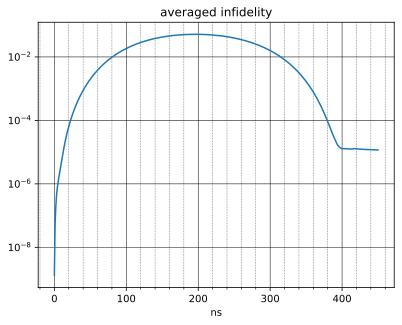

In [17]:
zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)
states_ideal  = [zero,
                one,
                (zero +  one).unit(),
                (zero - one).unit() ]

def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,dm_ideal in zip(dms,states_ideal):
        # new_dm = gate*dm*gate.dag()
        fid.append(qutip.fidelity(dm, gate*dm_ideal))
    return 1-sum(fid)/len(fid)


from scipy.optimize import minimize

infidelity = []
phase = []
for idx in range(num_time_steps):
    dms = [result.states[idx] for result in results]
    def objective_function(phase):
        return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
    initial_phase = [0.0]
    bounds = [(0, 2 * 3.141592653589793)]
    opt_result = minimize(objective_function, initial_phase,method="COBYLA")
    infidelity.append(opt_result.fun)
    phase.append(opt_result.x)


plt.plot(results[0].times,infidelity)
plt.grid(which='major', linestyle='-', linewidth='0.5', color='black')
plt.minorticks_on()
plt.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')

plt.yscale('log')
plt.title("averaged infidelity")
plt.xlabel("ns")

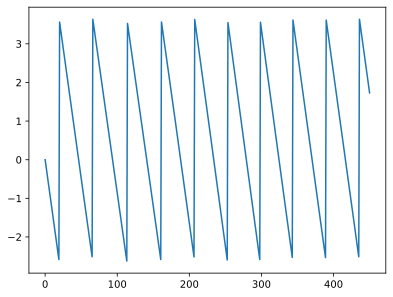

In [18]:
plt.plot(results[0].times,phase,label = f'phase')